In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.metrics import  accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier

In [169]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data cleaning


In [171]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"], errors='coerce')
df['TotalCharges']=df['TotalCharges'].fillna(0)
df['Churn']=df['Churn'].map({'No':0, 'Yes':1})
df.drop(columns=['customerID'], inplace=True)

df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Churn Ditribution

Overall Churn Rate:26.540000%


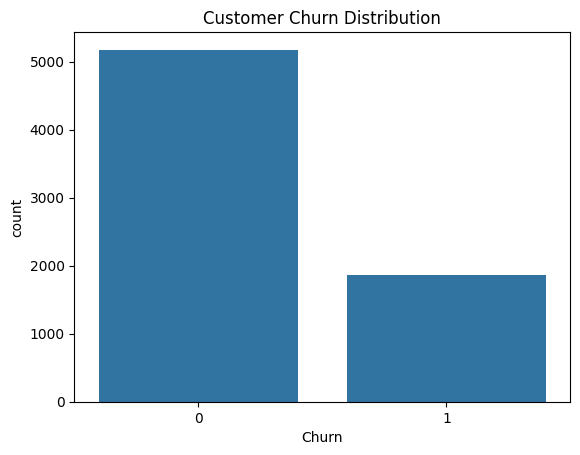

In [172]:
churn_rate=round((df['Churn'].mean()*100), 2)
print(f"Overall Churn Rate:{churn_rate:2f}%")


#churn distribution

sns.countplot(data=df, x='Churn')
plt.title("Customer Churn Distribution")
plt.show()

Churn                   0          1
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


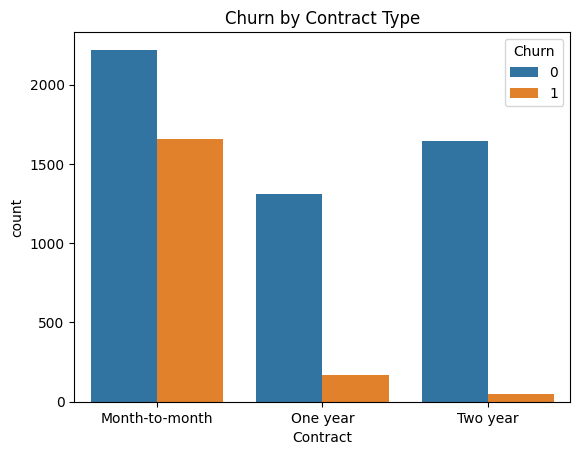

In [173]:
#churn by contract type
contract_churn=pd.crosstab(df['Contract'],df['Churn'], normalize='index')*100
print(contract_churn)

#visualization

sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.show()

Churn                              0          1
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


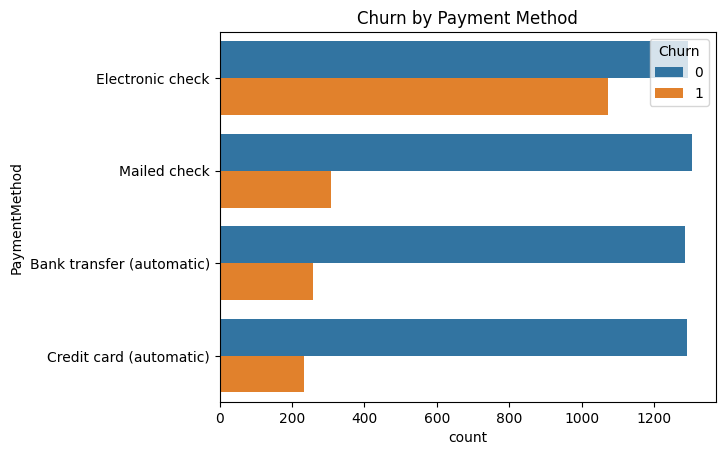

In [174]:
#Churn by Payment Method

payment_churn=pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')*100
print(payment_churn)

sns.countplot(data=df, y='PaymentMethod', hue='Churn')
plt.title("Churn by Payment Method")
plt.show()

/tmp/ipykernel_2996/1497939108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette=['skyblue', 'orange'])


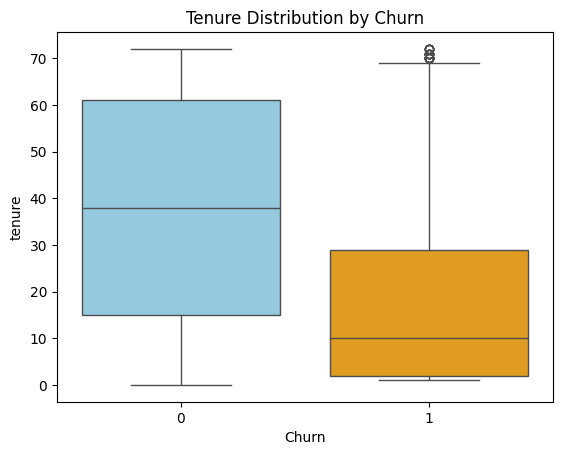

,mean,median,min,max
Churn,,,,
0,37.569965,38.0,0,72
1,17.979133,10.0,1,72


In [175]:
#Churn By tenure

sns.boxplot(data=df, x='Churn', y='tenure', palette=['skyblue', 'orange'])
plt.title("Tenure Distribution by Churn")
plt.show()

df.groupby('Churn')['tenure'].agg(['mean','median','min','max'])

/tmp/ipykernel_2996/997115077.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['skyblue', 'orange'])


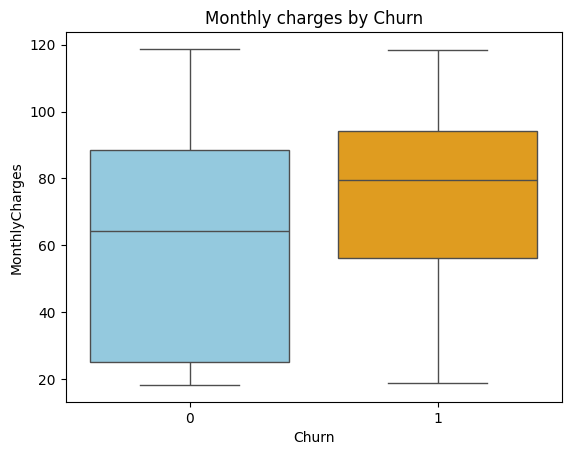

In [176]:
#Churn by Monthly charges

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['skyblue', 'orange'])
plt.title("Monthly charges by Churn")
plt.show()

## Statical Analysis

In [177]:
#Chi-Square test :contract and churn

from scipy.stats import chi2_contingency

contingency_table=pd.crosstab(df['Contract'], df['Churn'])

chi2, p_value,degrees_of_freedom, expected=chi2_contingency(contingency_table)

print("Chi-Square Staistics:", chi2)
print("P value:", p_value)

alpha=0.05

if(p_value<alpha):
  print("Contract type and Churn are statistically asssociated")

else:
  print("No statistically significant association was found")


Chi-Square Staistics: 1184.5965720837926
P value: 5.863038300673391e-258
Contract type and Churn are statistically asssociated


In [195]:
#T-Test

from scipy.stats import ttest_ind
churned_charges=df[df['Churn']==1]['MonthlyCharges']
retained_charges=df[df['Churn']==0]['MonthlyCharges']

statistic, p_value=ttest_ind(churned_charges, retained_charges, equal_var=False)
print("T-statistic:", statistic)
print("P value:", p_value)

if(p_value<alpha):
  print("Monthly charges are significantly different between churned and retained customers")
else:
  print("There is no statistically difffernce.")



T-statistic: 18.407526676414673
P value: 8.59244933154705e-73
Monthly charges are significantly different between churned and retained customers


## Feature Encoding

In [179]:
df=pd.get_dummies(df, drop_first=True)
df.head(1)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False


## Training and Testing


In [197]:
X=df.drop(columns=['Churn'])
y=df['Churn']
X_train,X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42,  stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 30)
(1409, 30)
(5634,)
(1409,)


## Feature scaling



In [198]:
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

# Machine Learning Model

In [200]:
#Logistic Regression

model_lr=LogisticRegression(max_iter=100)
model_lr.fit(X_train_scaled, y_train)

y_pred_lr=model_lr.predict(X_test_scaled)

accuracy_lr=round(accuracy_score(y_test, y_pred_lr)*100, 2)
print("Accuracy of LR model is:", accuracy_lr)

print("Classification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy of LR model is: 80.7
Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



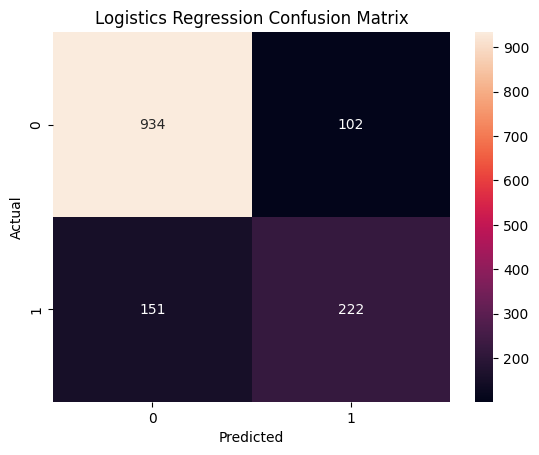

In [196]:
#Creating Confusion matrix

cm=confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistics Regression Confusion Matrix")

plt.show()

In [201]:
#Decison Tree

model_dt=DecisionTreeClassifier()

model_dt.fit(X_train_scaled, y_train)
y_pred_dt=model_dt.predict(X_test_scaled)

accuracy_dt=round(accuracy_score(y_test, y_pred_dt)*100,2)
print("Accuracy of DT model is:", accuracy_dt)

print("Classifiaction Report")
print(classification_report(y_test, y_pred_dt))

Accuracy of DT model is: 73.39
Classifiaction Report
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.50      0.49      0.50       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



In [202]:
#Random Forest

model_rf=RandomForestClassifier()

model_rf.fit(X_train_scaled, y_train)
y_pred_rf=model_rf.predict(X_test_scaled)\

accuracy_rf=round(accuracy_score(y_test, y_pred_rf)*100, 2)
print("Accuracy of RF model is:", accuracy_rf)

print("Classification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy of RF model is: 79.13
Classification Report
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [203]:
#Bagging Classifier

bag_model=BaggingClassifier(n_estimators=100, random_state=42)

bag_model.fit(X_train_scaled,y_train)
y_pred_bag=bag_model.predict(X_test_scaled)

accuracy_bag=round(accuracy_score(y_test, y_pred_bag)*100,2)
print("Accuracy of Bag model is:", accuracy_bag)

print("Classificatio Report")
print(classification_report(y_test, y_pred_bag))

Accuracy of Bag model is: 78.14
Classificatio Report
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [204]:
#Calculating accuracy for all models

results=pd.DataFrame({
    "Model":["LogisticsRegression", "DecisionTreeClassifier", "RandomForestClassifier", "BaggingClassifier"],

    "Accuracy":[round(accuracy_score(y_test, y_pred_lr)*100,2),round(accuracy_score(y_test, y_pred_dt)*100,2),
    round(accuracy_score(y_test, y_pred_rf)*100,2),round(accuracy_score(y_test, y_pred_bag)*100,2)]

})

results

,Model,Accuracy
0,LogisticsRegression,80.70
1,DecisionTreeClassifier,73.39
2,RandomForestClassifier,79.13
3,BaggingClassifier,78.14


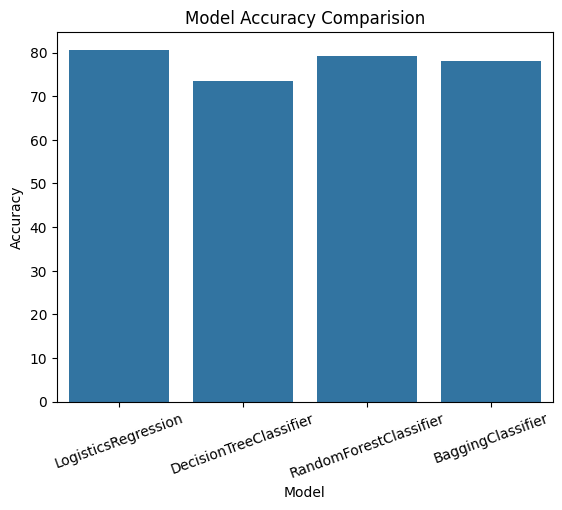

In [205]:
#visulazing model

sns.barplot(data=results, x="Model", y="Accuracy")

plt.title("Model Accuracy Comparision")
plt.xticks(rotation=20)

plt.show()

## Top 15 impotant features

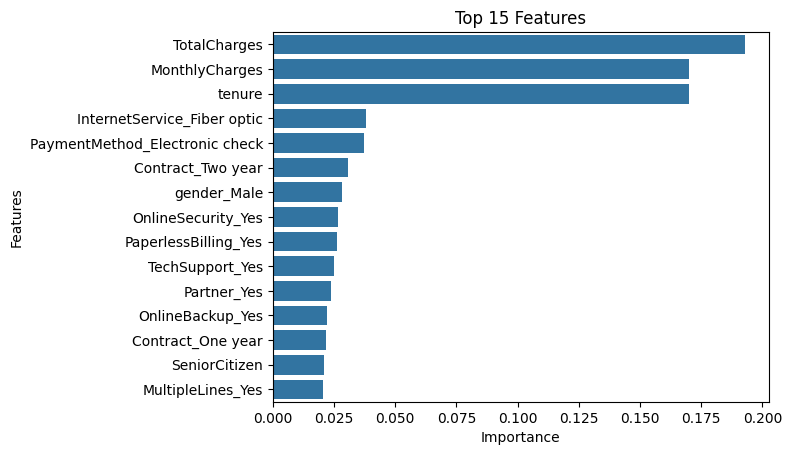

In [206]:
importance=pd.DataFrame({
    "Features":X_train.columns,
    "Importance":model_rf.feature_importances_
})

importance=importance.sort_values(by="Importance", ascending=False)
importance.head(5)

#Plotting top 15 features

top_features=importance.head(15)

sns.barplot(data=top_features, x="Importance", y="Features")
plt.title("Top 15 Features")
plt.show()

## Error Analysis

In [207]:
errors=X_test.copy()
errors["Actual"]=y_test.values
errors["Predicted"]=y_pred_lr

errors[
    errors["Actual"] !=errors["Predicted"]
].head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual,Predicted
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,False,True,False,False,True,True,False,False,0,1
5748,0,21,99.85,1992.55,False,False,False,True,False,True,...,False,True,False,False,True,True,False,False,0,1
1639,1,17,45.05,770.60,True,False,False,True,False,False,...,False,False,False,False,True,False,True,False,1,0
2136,0,15,91.00,1430.05,True,False,True,True,False,True,...,False,False,False,False,True,False,True,False,0,1
950,1,2,44.95,85.15,True,False,False,True,False,False,...,False,False,False,False,False,False,False,True,1,0


In [208]:
#Finding False poasitive and False negative

cm=confusion_matrix(y_test, y_pred_lr)

tn,fp,fn,tp=cm.ravel()

print("True Negative:", tn)
print("False positive:", fp)
print("False Negative:", fn)
print("True positive:", tp)

True Negative: 925
False positive: 110
False Negative: 162
True positive: 212


## Sample Customer Churn Predictions



In [209]:
for i in range(15):
  new_customer=X.iloc[[i]].copy()
  prediction=model_lr.predict(sc.transform(new_customer))
  print("Customer",i,"Prediction:", prediction)



Customer 0 Prediction: [1]
Customer 1 Prediction: [0]
Customer 2 Prediction: [0]
Customer 3 Prediction: [0]
Customer 4 Prediction: [1]
Customer 5 Prediction: [1]
Customer 6 Prediction: [0]
Customer 7 Prediction: [0]
Customer 8 Prediction: [1]
Customer 9 Prediction: [0]
Customer 10 Prediction: [0]
Customer 11 Prediction: [0]
Customer 12 Prediction: [0]
Customer 13 Prediction: [0]
Customer 14 Prediction: [0]


## Correlation matrix for numerical values

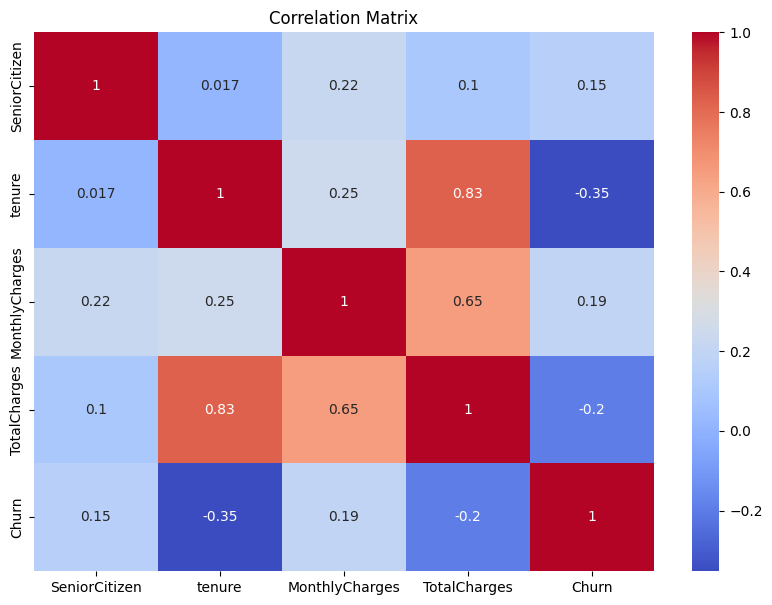

In [210]:
#creation of correlation matrix for numerical values

numeric_df=df.select_dtypes(

    include=["int64", "float64"]
)

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()